In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Equilibration

Start with equilibration for Montecarlo: I run the simulation for 500 blocks of 1 step each and plot. See that after 500 steps the system is well equilibrated. Restart from the configuration reached copying the output config.xyz into the input conf-1.xyz

In [86]:
path_eq_MC = "NSL_SIMULATOR/OUTPUT/BACKUP/EQUILIBRATION/MONTECARLO/"

In [87]:
_, quilibration_U, _, _ = np.loadtxt(path_eq_MC + "potential_energy_MC_eq.dat", unpack=True)

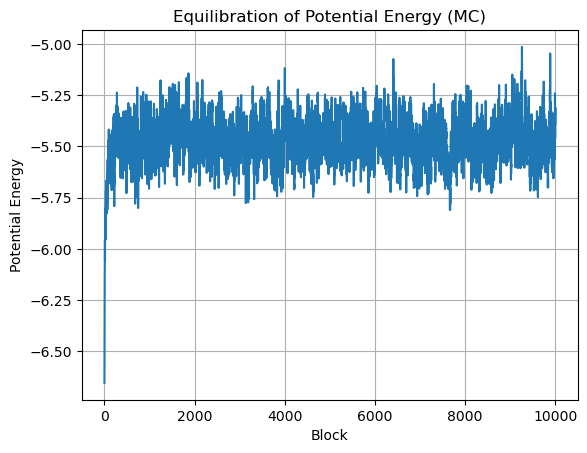

In [88]:
plt.plot(quilibration_U, label="Actual Potential Energy (MC)")
plt.xlabel("Block")
plt.ylabel("Potential Energy")
plt.title("Equilibration of Potential Energy (MC)")
plt.grid()
plt.show()

Now equilibration for molecular dynamic

In [89]:
path_eq_MD = "NSL_SIMULATOR/OUTPUT/BACKUP/EQUILIBRATION/MD/"

In [90]:
_, temperature_MD, _, _ = np.loadtxt(path_eq_MD + "temperature.dat", unpack=True)
_, potential_energy_MD, _, _ = np.loadtxt(path_eq_MD + "potential_energy.dat", unpack=True)

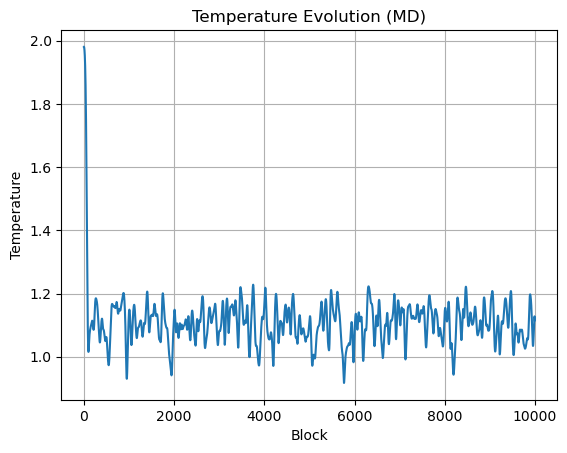

In [91]:
plt.plot(temperature_MD, label="Actual Temperature (MD)")
plt.xlabel("Block")
plt.ylabel("Temperature")
plt.title("Temperature Evolution (MD)")
plt.grid()
plt.show()

In [92]:
temperature_mean = np.mean(temperature_MD[1000:])  # Average over the last 9000 steps
print(f"Average Temperature (MD): {temperature_mean:.2f}")
print(f"Standard Deviation of Temperature (MD): {np.std(temperature_MD[1000:]):.2f}")

Average Temperature (MD): 1.10
Standard Deviation of Temperature (MD): 0.05


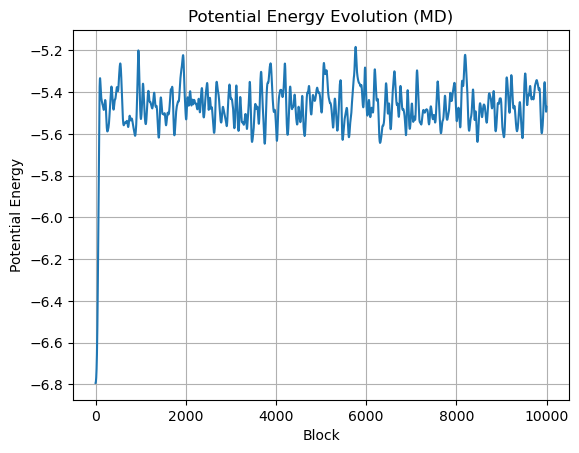

In [93]:
plt.plot(potential_energy_MD, label="Potential energy (MD)")
plt.xlabel("Block")
plt.ylabel("Potential Energy")
plt.title("Potential Energy Evolution (MD)")
plt.grid()
plt.show()

# Autocorrelation

In [94]:
def autocorrelation(data, tau):
    if tau >= len(data):
        raise ValueError("Autocorrelation time tau must be less than the maximum time tmax")
    
    ## For tau=0 autocorrelation is 1: avoid useless calculations
    #if tau == 0:
    #    return 1.0
        
    t_max = len(data)
    
    # Denominator: variance of the entire dataset
    denominator = np.var(data)

    # data_start: m(t')
    # data_end: m(t'+t)
    data_start = data[:t_max - tau]
    data_end = data[tau:]
    
    term1 = np.mean(data_start * data_end)
    term2 = np.mean(data_start) * np.mean(data_end)
    
    numerator = term1 - term2
    
    return numerator / denominator



# Function for exponential decay fit
def exponential_decay(tau, tau_c):
    return np.exp(-tau / tau_c)

# Execution of Montecarlo 500000 steps: instantaneous values for potential energy

In [95]:
path_MC = "NSL_SIMULATOR/OUTPUT/BACKUP/MONTECARLO/"

In [96]:
_, potential_energy_MC, _, _ = np.loadtxt(path_MC + "potential_energy.dat", unpack=True)

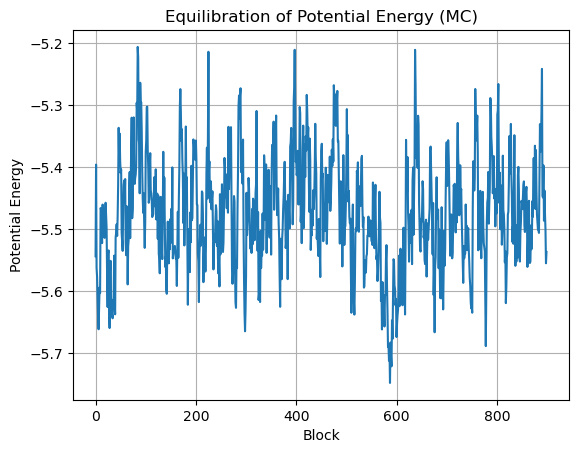

In [97]:
plt.plot(potential_energy_MC[:900], label="Actual Potential Energy (MC)")
plt.xlabel("Block")
plt.ylabel("Potential Energy")
plt.title("Equilibration of Potential Energy (MC)")
plt.grid()
plt.show()

In [98]:
tau = np.arange(0, 300, 1)
autocorr_values = [autocorrelation(potential_energy_MC, t) for t in tau]

# Perform the exponential fit (starting from index 1 to avoid tau=0 where Ac=1 perfectly)
popt, pcov = curve_fit(exponential_decay, tau[1:], autocorr_values[1:])
tau_c = popt[0]

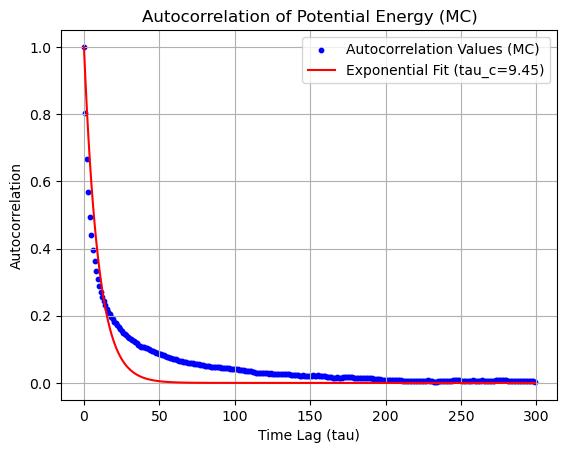

In [99]:
plt.scatter(tau, autocorr_values, label="Autocorrelation Values (MC)", color='blue', s=10)
plt.plot(tau, exponential_decay(tau, tau_c), label=f"Exponential Fit (tau_c={tau_c:.2f})", color='red')
#plt.yscale('log')
plt.xlabel("Time Lag (tau)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Potential Energy (MC)")
plt.grid()
plt.legend()
plt.show()

# Execution of Molecular Dynamics

In [100]:
path_MD = "NSL_SIMULATOR/OUTPUT/BACKUP/MD/"

In [101]:
_, potential_energy_MD, _, _ = np.loadtxt(path_MD + "potential_energy.dat", unpack=True)

In [102]:
tau = np.arange(0, 1000, 1)
autocorr_values = [autocorrelation(potential_energy_MD, t) for t in tau]

# Perform the exponential fit (starting from index 1 to avoid tau=0 where Ac=1 perfectly)
#popt, pcov = curve_fit(exponential_decay, tau[1:], autocorr_values[1:])
#tau_c = popt[0]

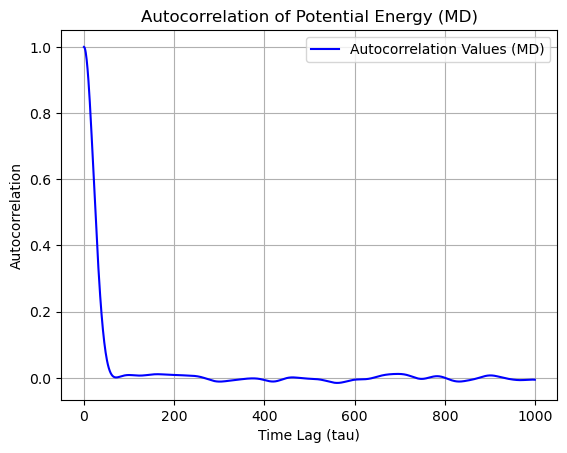

In [103]:
plt.plot(tau, autocorr_values, label="Autocorrelation Values (MD)", color='blue')
#plt.plot(tau, exponential_decay(tau, tau_c), label=f"Exponential Fit (tau_c={tau_c:.2f})", color='red')
#plt.yscale('log')
plt.xlabel("Time Lag (tau)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Potential Energy (MD)")
plt.grid()
plt.legend()
plt.show()

È dinamica molecolare quindi non è una traiettoria stocastica, non è giusto dire che è scorrelata a un certo punto perché è sempre correlata essendo la soluzione di una traiettoria teorica non è una cosa stocastica. L'autocorrelazione si riduce ma in realtà la traiettoria non è scorrelata. È sempre correlata e quando l'autocorrelazione è negativa vuol dire che è anticorrelata.

Per individuare una dimensione del blocco devo fare una scelta. Qui pare che dopo 300 passi si possa considerare "scorrelata" in senso improprio. Per capire se le 4 gobbe che compaiono dopo sono ritorni di memoria oppure se sono cose casuali, faccio un'altra simulazione proseguendo dallo stato a cui ero arrivata. Se ricompaiono sono ritorni di memoria e quindi facciamo la grossolana approssimazione di non considerarlo perché sono dell'ordine di 0.01. Se invece non ritornano o ritornano in punti diversi allora sono cose casuali che possiamo ignorare con più serenità.

In [104]:
_, potential_energy_MD2, _, _ = np.loadtxt(path_MD + "potential_energy2.dat", unpack=True)

In [105]:
tau = np.arange(0, 1000, 1)
autocorr_values = [autocorrelation(potential_energy_MD2, t) for t in tau]

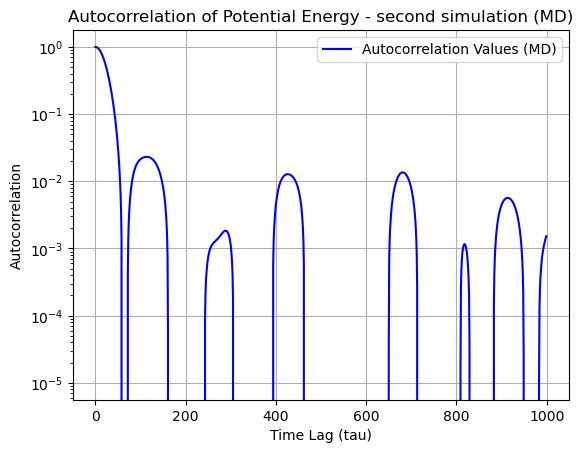

In [106]:
plt.plot(tau, autocorr_values, label="Autocorrelation Values (MD)", color='blue')
#plt.plot(tau, exponential_decay(tau, tau_c), label=f"Exponential Fit (tau_c={tau_c:.2f})", color='red')
plt.yscale('log')
plt.xlabel("Time Lag (tau)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Potential Energy - second simulation (MD)")
plt.grid()
plt.legend()
plt.show()

In [107]:
# Plot temperature

_, temperature_MD, _, _ = np.loadtxt(path_MD + "temperature.dat", unpack=True)
_, potential_energy_MD, _, _ = np.loadtxt(path_MD + "potential_energy.dat", unpack=True)

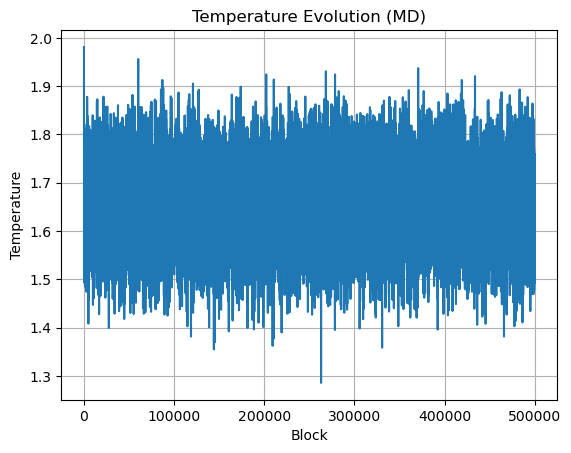

In [108]:
plt.plot(temperature_MD, label="Actual Temperature (MD)")
plt.xlabel("Block")
plt.ylabel("Temperature")
plt.title("Temperature Evolution (MD)")
plt.grid()
plt.show()

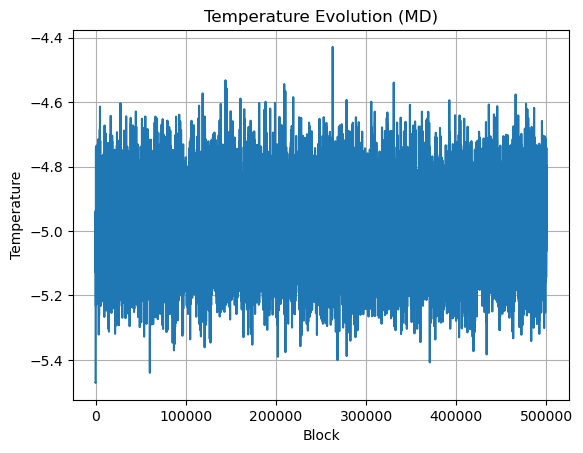

In [109]:
plt.plot(potential_energy_MD, label="Actual Temperature (MD)")
plt.xlabel("Block")
plt.ylabel("Temperature")
plt.title("Temperature Evolution (MD)")
plt.grid()
plt.show()

Consideriamo blocchi da 5000 step, dovrebbero essere sufficienti per garantire medie scorrelate (sicuro per il montecarlo, per il dinamica molecolare facciamo questa approssimazione)

# Data blocking analysis

In [110]:
block_size = np.arange(10, 1010, 10)

## Montecarlo

In [111]:
_, potential_energy_MC, _, _ = np.loadtxt(path_MC + "potential_energy.dat", unpack=True)

In [112]:
def data_blocking_error(data, L):
    # Number of full blocks
    N = len(data) // L
    
    if N <= 1:
        return 0.0 # Only one block no uncertainty
    
    # Truncate the data array to make it the length of a multiple of L
    data_truncated = data[:N*L]
    
    # Data reorganized in a matrix of N rows and L columns
    # Each row is a block
    blocks = data_truncated.reshape(N, L)
    
    # Block mean: sum along the row (the column index shifts)
    block_means = np.mean(blocks, axis=1)
    
    global_mean = np.mean(block_means)
    global_mean_squared = np.mean(block_means**2)
    
    # Statistical error
    error = np.sqrt((global_mean_squared - global_mean**2) / (N - 1))
    
    return error

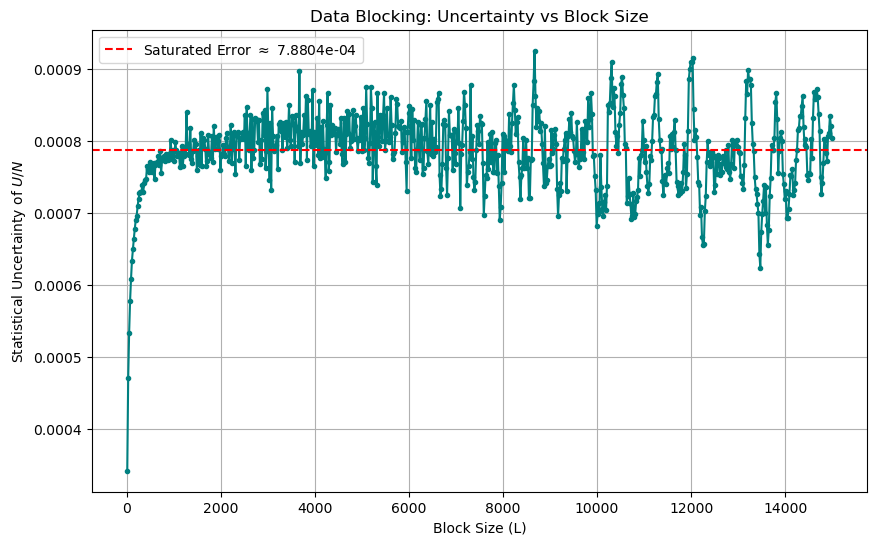

In [116]:
# ==========================================
# EXECUTION ON MONTECARLO
# ==========================================

L_values = np.arange(10, 15001, 20) 

# Error for each value of L
errors = [data_blocking_error(potential_energy_MC, L) for L in L_values]

plt.figure(figsize=(10, 6))
plt.plot(L_values, errors, marker='o', markersize=3, linestyle='-', color='teal')
plt.xlabel("Block Size (L)")
plt.ylabel("Statistical Uncertainty of $U/N$")
plt.title("Data Blocking: Uncertainty vs Block Size")
plt.grid(True)

# Horizontal line for saturation: last 50 points
saturated_error = np.mean(errors[-50:])
plt.axhline(saturated_error, color='red', linestyle='--', label=f'Saturated Error $\\approx$ {saturated_error:.4e}')

plt.legend()
plt.show()

# TODO: ripetere cambiando seme
# Removed trend with 10000 steps of equilibration

In [114]:
_, potential_energy_MD, _, _ = np.loadtxt(path_MD + "potential_energy.dat", unpack=True)

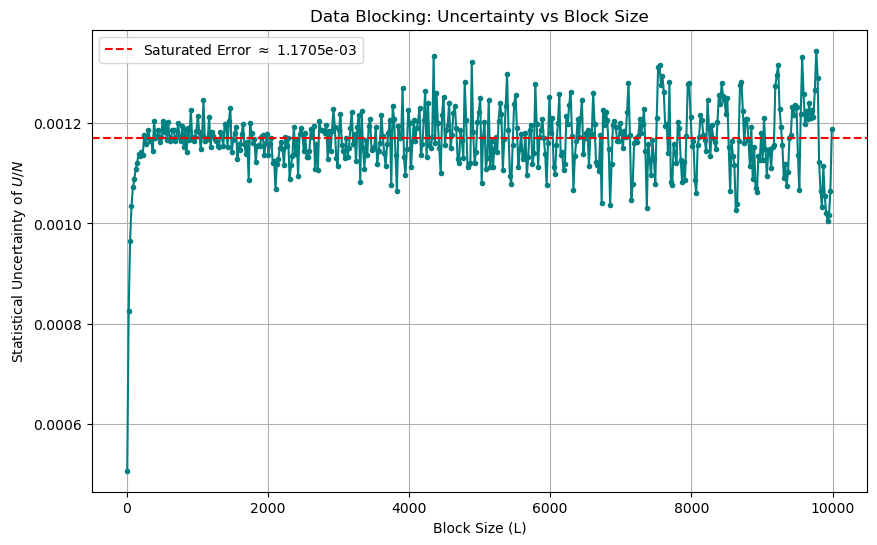

In [115]:
# ==========================================
# EXECUTION ON MOLECULAR DYNAMICS
# ==========================================

L_values = np.arange(10, 10001, 20) 

errors = [data_blocking_error(potential_energy_MD, L) for L in L_values]


plt.figure(figsize=(10, 6))
plt.plot(L_values, errors, marker='o', markersize=3, linestyle='-', color='teal')
plt.xlabel("Block Size (L)")
plt.ylabel("Statistical Uncertainty of $U/N$")
plt.title("Data Blocking: Uncertainty vs Block Size")
plt.grid(True)

saturated_error = np.mean(errors[-50:])
plt.axhline(saturated_error, color='red', linestyle='--', label=f'Saturated Error $\\approx$ {saturated_error:.4e}')

plt.legend()
plt.show()